##Understanding and Implementing K-Means and DBSCAN Algorithms

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA


In [5]:

# ==========================================
# 1. DATA LOADING & PREPROCESSING
# ==========================================

# Load dataset (Replace with your file path)
df = pd.read_excel('/content/EastWestAirlines.xlsx',sheet_name='data')

# Drop unique identifiers (ID#) and non-numeric columns if any
# We also drop the 'Award?' column as we want to see if clusters form naturally without it
data_for_clustering = df.drop(['ID#', 'Award?'], axis=1)

# Handle Missing Values (if any)
data_for_clustering = data_for_clustering.fillna(data_for_clustering.mean())

# Feature Scaling (Crucial for distance-based algorithms)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(data_for_clustering)


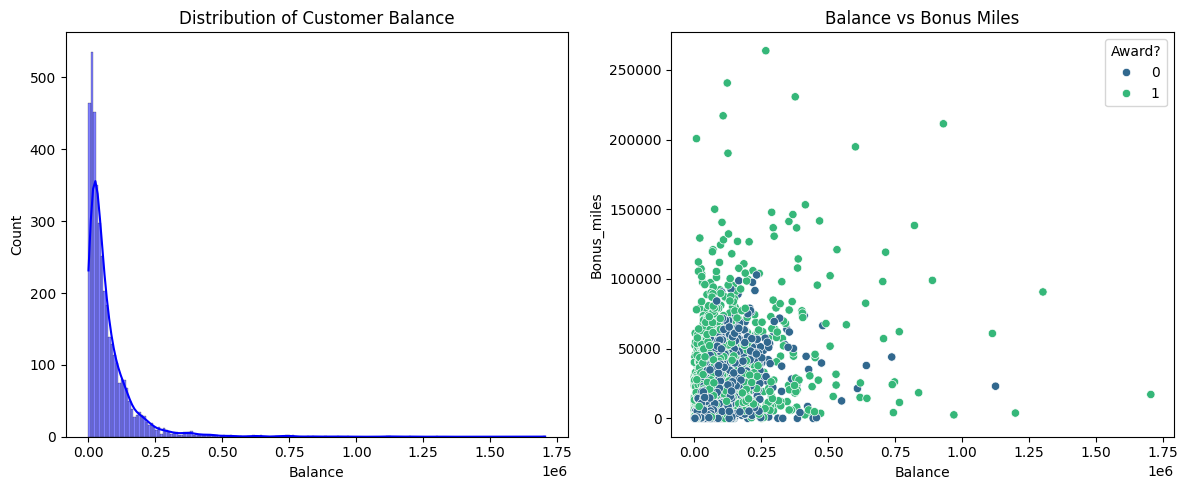

In [6]:
# ==========================================
# 2. EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['Balance'], kde=True, color='blue')
plt.title('Distribution of Customer Balance')

plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='Balance', y='Bonus_miles', hue='Award?', palette='viridis')
plt.title('Balance vs Bonus Miles')
plt.tight_layout()
plt.show()

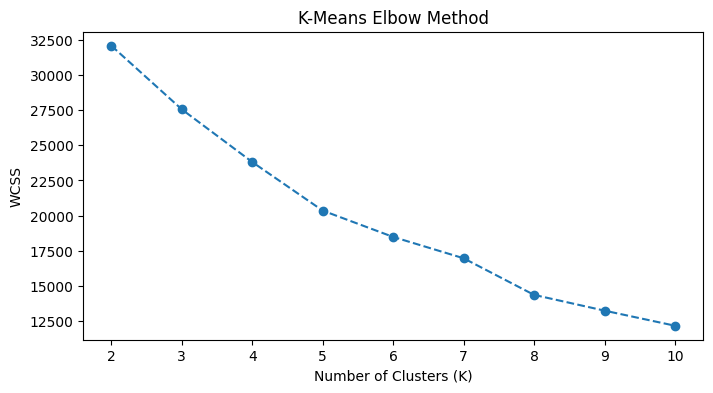

In [7]:
# ==========================================
# 3. K-MEANS CLUSTERING
# ==========================================

# Elbow Method to find optimal K
wcss = []
k_range = range(2, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.title('K-Means Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.show()

# Final K-Means Implementation (using K=5 as an example from the elbow)
kmeans_final = KMeans(n_clusters=5, random_state=42, n_init=10)
df['KMeans_Labels'] = kmeans_final.fit_predict(scaled_features)

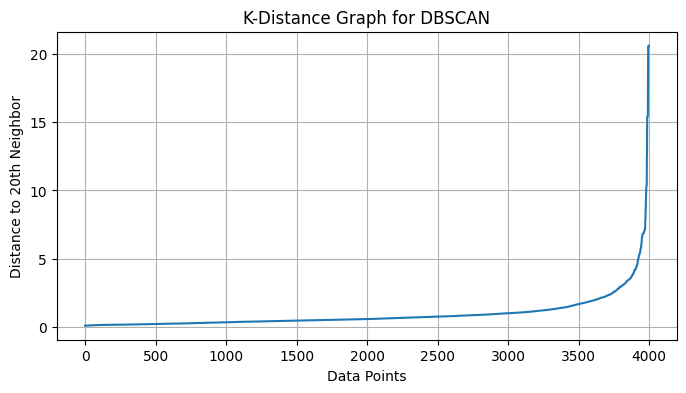

In [8]:
# ==========================================
# 4. DBSCAN CLUSTERING
# ==========================================

# Parameter Tuning: Finding optimal Epsilon (eps) using K-Distance Graph
# Heuristic for min_samples: 2 * dimensions
min_pts = 2 * scaled_features.shape[1]
nn = NearestNeighbors(n_neighbors=min_pts)
nn.fit(scaled_features)
distances, indices = nn.kneighbors(scaled_features)

# Sort and plot the distances to the k-th nearest neighbor
distances = np.sort(distances[:, min_pts-1], axis=0)
plt.figure(figsize=(8, 4))
plt.plot(distances)
plt.title('K-Distance Graph for DBSCAN')
plt.ylabel(f'Distance to {min_pts}th Neighbor')
plt.xlabel('Data Points')
plt.grid(True)
plt.show()

# Implementing DBSCAN (adjust eps based on the "knee" in the graph above)
dbscan = DBSCAN(eps=1.5, min_samples=min_pts)
df['DBSCAN_Labels'] = dbscan.fit_predict(scaled_features)

In [9]:
# ==========================================
# 5. EVALUATION & PERFORMANCE METRICS
# ==========================================

km_sil = silhouette_score(scaled_features, df['KMeans_Labels'])
print(f"K-Means Silhouette Score: {km_sil:.3f}")

# DBSCAN silhouette score (ignoring noise points labeled as -1)
dbscan_mask = df['DBSCAN_Labels'] != -1
if len(set(df['DBSCAN_Labels'][dbscan_mask])) > 1:
    db_sil = silhouette_score(scaled_features[dbscan_mask], df['DBSCAN_Labels'][dbscan_mask])
    print(f"DBSCAN Silhouette Score (excluding noise): {db_sil:.3f}")
else:
    print("DBSCAN did not find enough clusters for a Silhouette Score.")

K-Means Silhouette Score: 0.348
DBSCAN did not find enough clusters for a Silhouette Score.


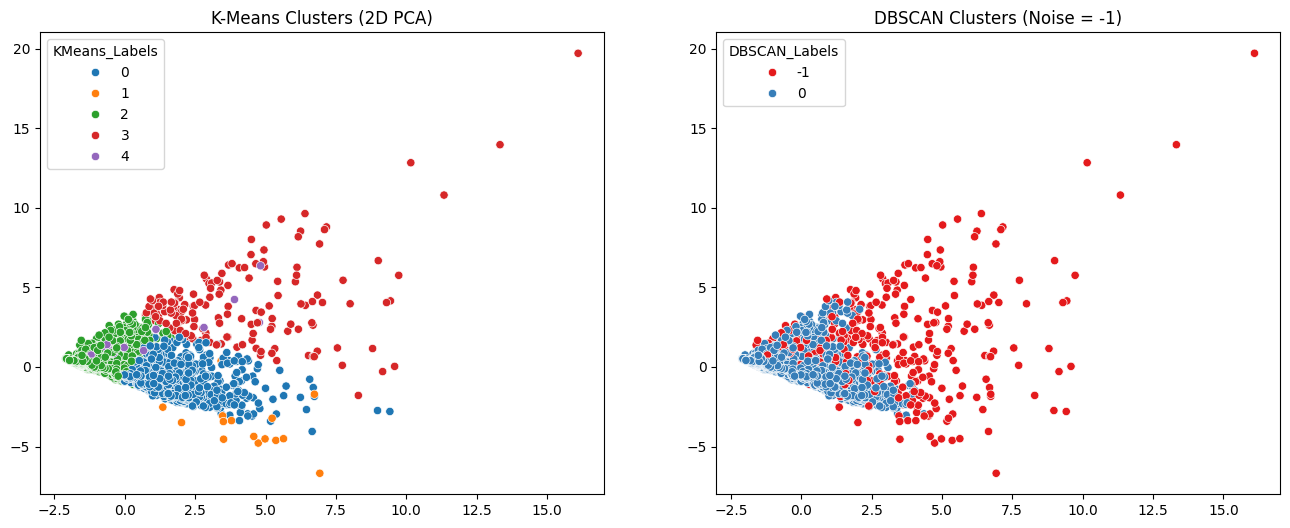

In [10]:
# ==========================================
# 6. VISUALIZATION (PCA Projection)
# ==========================================

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_features)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot K-Means
sns.scatterplot(x=pca_data[:, 0], y=pca_data[:, 1], hue=df['KMeans_Labels'], palette='tab10', ax=ax1)
ax1.set_title('K-Means Clusters (2D PCA)')

# Plot DBSCAN
sns.scatterplot(x=pca_data[:, 0], y=pca_data[:, 1], hue=df['DBSCAN_Labels'], palette='Set1', ax=ax2)
ax2.set_title('DBSCAN Clusters (Noise = -1)')

plt.show()

In [12]:
# ==========================================
# 7. CLUSTER ANALYSIS & INTERPRETATION
# ==========================================

print("\n--- K-Means Cluster Characteristics (Mean Values) ---")
analysis = df.drop('ID#', axis=1).groupby('KMeans_Labels').mean()
print(analysis)


--- K-Means Cluster Characteristics (Mean Values) ---
                     Balance  Qual_miles  cc1_miles  cc2_miles  cc3_miles  \
KMeans_Labels                                                               
0              114669.122132  138.739452   3.673575   1.000000   1.001480   
1              138061.400000   78.800000   3.466667   1.000000   4.066667   
2               42727.317304  106.555282   1.160707   1.000000   1.000411   
3              193793.299363  811.757962   2.216561   1.000000   1.000000   
4               68876.581395   23.255814   1.139535   2.348837   1.000000   

                Bonus_miles  Bonus_trans  Flight_miles_12mo  Flight_trans_12  \
KMeans_Labels                                                                  
0              37957.501110    18.669874         317.646928         0.948187   
1              93927.866667    28.066667         506.666667         1.600000   
2               4136.191533     6.466091         212.853679         0.646938   
3    


INSIGHTS:
1. K-Means effectively segments the population into size-based groups (e.g., High Balance vs Low Balance).
2. DBSCAN is highly useful for identifying 'Noise' (-1). These points are outliers who have
   extreme flight miles or unusual bonus transactions that don't fit typical patterns.
3. K-Means is better for marketing segmentation, whereas DBSCAN is better for outlier/fraud detection.
